### Impact of Padding and Strides in Convolutional Layers

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

▶ Running: Baseline

▶ Running: Valid-Only

▶ Running: Stride-2 (S)

▶ Running: Stride-2 (V)

  Experiment Padding  Stride  Params  Train Time(s)  Test Accuracy
    Baseline    same       1  421642          19.78         0.9907
  Valid-Only   valid       1  225034          16.63         0.9903
Stride-2 (S)    same       2   53002          14.38         0.9812
Stride-2 (V)   valid       2   28426          13.93         0.9717


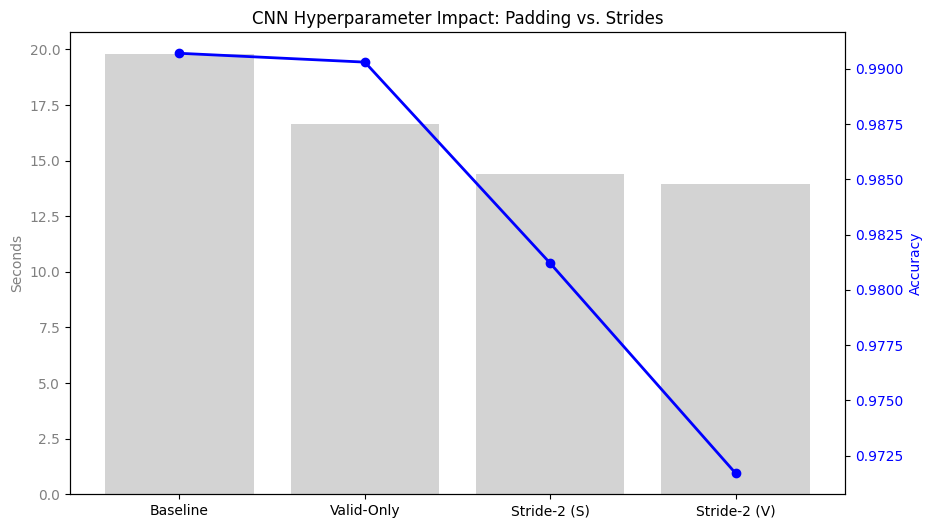

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# ────────────────────────────────────────────────
# 1. Data Pipeline
# ────────────────────────────────────────────────
def load_mnist_data():
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
    # Normalize and reshape
    x_train = x_train.astype("float32") / 255.0
    x_test  = x_test.astype("float32")  / 255.0
    x_train = np.expand_dims(x_train, -1)
    x_test  = np.expand_dims(x_test, -1)
    # One-hot encoding
    y_train = keras.utils.to_categorical(y_train, 10)
    y_test  = keras.utils.to_categorical(y_test, 10)
    return x_train, y_train, x_test, y_test

x_train, y_train, x_test, y_test = load_mnist_data()

# ────────────────────────────────────────────────
# 2. Configurable CNN Factory
# ────────────────────────────────────────────────
def build_experiment_model(padding='valid', strides=(1,1)):
    model = keras.Sequential([
        layers.Input(shape=(28,28,1)),
        # Layer 1
        layers.Conv2D(32, (3,3), padding=padding, strides=strides, activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        # Layer 2
        layers.Conv2D(64, (3,3), padding=padding, strides=strides, activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ────────────────────────────────────────────────
# 3. Experiment Loop
# ────────────────────────────────────────────────
configs = [
    {"name": "Baseline", "p": "same",  "s": (1,1)},
    {"name": "Valid-Only", "p": "valid", "s": (1,1)},
    {"name": "Stride-2 (S)", "p": "same",  "s": (2,2)},
    {"name": "Stride-2 (V)", "p": "valid", "s": (2,2)},
]

results_list = []

for conf in configs:
    print(f"\n▶ Running: {conf['name']}")
    model = build_experiment_model(padding=conf['p'], strides=conf['s'])

    # Track performance
    start = time.time()
    history = model.fit(x_train, y_train, batch_size=128, epochs=5, validation_split=0.1, verbose=0)
    duration = round(time.time() - start, 2)

    # Evaluate
    _, acc = model.evaluate(x_test, y_test, verbose=0)

    results_list.append({
        "Experiment": conf['name'],
        "Padding": conf['p'],
        "Stride": conf['s'][0],
        "Params": model.count_params(),
        "Train Time(s)": duration,
        "Test Accuracy": round(acc, 4)
    })

# ────────────────────────────────────────────────
# 4. Reporting & Visualization
# ────────────────────────────────────────────────
df = pd.DataFrame(results_list)
print("\n" + "="*70)
print(df.to_string(index=False))
print("="*70)

# Visualization of Accuracy vs. Speed
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for Training Time
ax1.bar(df['Experiment'], df['Train Time(s)'], color='lightgray', label='Train Time (s)')
ax1.set_ylabel('Seconds', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

# Line chart for Accuracy
ax2 = ax1.twinx()
ax2.plot(df['Experiment'], df['Test Accuracy'], color='blue', marker='o', linewidth=2, label='Accuracy')
ax2.set_ylabel('Accuracy', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('CNN Hyperparameter Impact: Padding vs. Strides')
plt.show()

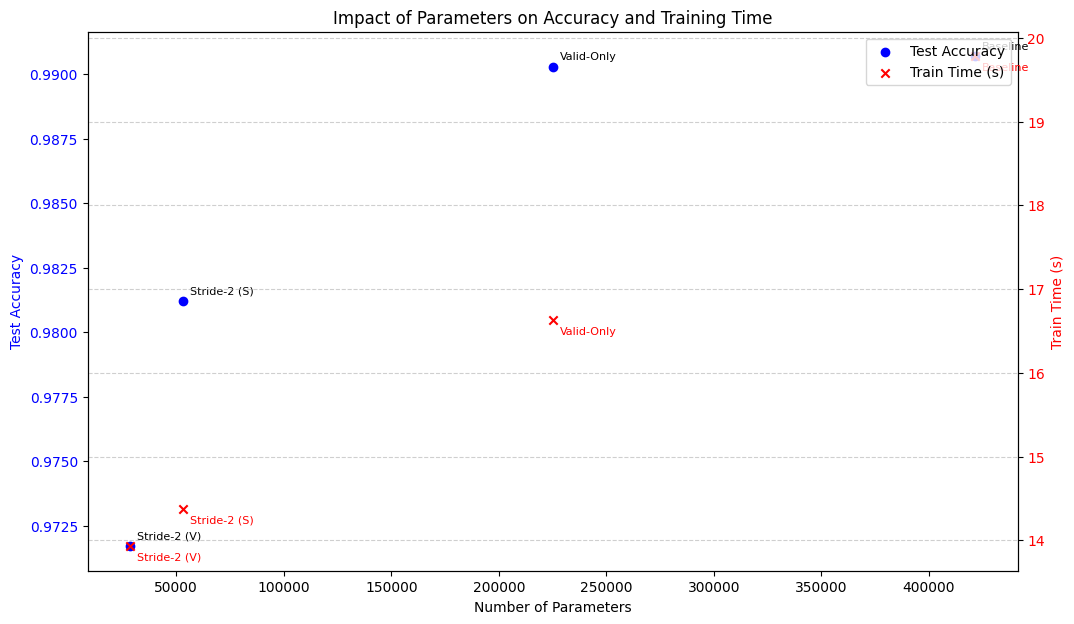

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Test Accuracy on primary y-axis (ax1)
ax1.scatter(df['Params'], df['Test Accuracy'], color='blue', marker='o', label='Test Accuracy')
ax1.set_xlabel('Number of Parameters')
ax1.set_ylabel('Test Accuracy', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis (ax2) for Train Time(s)
ax2 = ax1.twinx()
ax2.scatter(df['Params'], df['Train Time(s)'], color='red', marker='x', label='Train Time (s)')
ax2.set_ylabel('Train Time (s)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Annotate each point with the experiment name
for i, row in df.iterrows():
    ax1.annotate(row['Experiment'], (row['Params'], row['Test Accuracy']), textcoords="offset points", xytext=(5,5), ha='left', fontsize=8)
    ax2.annotate(row['Experiment'], (row['Params'], row['Train Time(s)']), textcoords="offset points", xytext=(5,-10), ha='left', fontsize=8, color='red')

# Add title and legend
plt.title('Impact of Parameters on Accuracy and Training Time')

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()